In [19]:
import pandas as pd
import numpy as np

# Load the dataset and compute residual_MWh (same as eda-1.ipynb)
df = pd.read_parquet("/Users/ryanaskin/Documents/datasci-challenge/renewables-dataset.parquet")
df["Time"] = pd.to_datetime(df["Time"])

a_s = 0.01  # solar penetration
a_w = 0.05  # wind penetration
df["residual_MWh"] = df["demand_MWh"] - (a_s * df["solar_MWh"] + a_w * df["wind_MWh"])


In [20]:
country_df = (
    df.groupby(['Time', 'country'], as_index=False)
      .agg(demand_MWh=('demand_MWh', 'sum'),
           solar_MWh=('solar_MWh', 'sum'),
           wind_MWh=('wind_MWh', 'sum'),
           residual_MWh=('residual_MWh', 'sum'))
)
country_df['Time'] = pd.to_datetime(country_df['Time'], utc=True)
country_df = country_df.sort_values(['country', 'Time']).reset_index(drop=True)

In [18]:
country_df[country_df["country"] == "ALB"]

,Time,country,demand_MWh,solar_MWh,wind_MWh,residual_MWh
0,2012-01-01 00:00:00+00:00,ALB,930.7072,0.0,331.020628,914.156169
1,2012-01-01 01:00:00+00:00,ALB,915.5938,0.0,303.483632,900.419618
2,2012-01-01 02:00:00+00:00,ALB,861.6299,0.0,266.839535,848.287923
3,2012-01-01 03:00:00+00:00,ALB,812.0605,0.0,225.270603,800.796970
4,2012-01-01 04:00:00+00:00,ALB,768.4864,0.0,192.234428,758.874679
...,...,...,...,...,...,...
26299,2014-12-31 19:00:00+00:00,ALB,1176.7311,0.0,985.389336,1127.461633
26300,2014-12-31 20:00:00+00:00,ALB,1120.5878,0.0,949.948769,1073.090362
26301,2014-12-31 21:00:00+00:00,ALB,1050.6820,0.0,932.349372,1004.064531
26302,2014-12-31 22:00:00+00:00,ALB,1010.8949,0.0,850.321911,968.378804


In [22]:
import pandas as pd

COUNTRY_TZ = {
    'POR': 'Europe/Lisbon',       'ESP': 'Europe/Madrid',
    'FRA': 'Europe/Paris',        'BEL': 'Europe/Brussels',
    'CHE': 'Europe/Zurich',       'LUX': 'Europe/Luxembourg',
    'NLD': 'Europe/Amsterdam',    'ITA': 'Europe/Rome',
    'DEU': 'Europe/Berlin',       'AUT': 'Europe/Vienna',
    'DNK': 'Europe/Copenhagen',   'CZE': 'Europe/Prague',
    'POL': 'Europe/Warsaw',       'HUN': 'Europe/Budapest',
    'SVK': 'Europe/Bratislava',   'SVN': 'Europe/Ljubljana',
    'HRV': 'Europe/Zagreb',       'GRC': 'Europe/Athens',
    'ALB': 'Europe/Tirane',       'MKD': 'Europe/Skopje',
    'BGR': 'Europe/Sofia',        'MNE': 'Europe/Podgorica',
    'BIH': 'Europe/Sarajevo',     'SRB': 'Europe/Belgrade',
    'ROU': 'Europe/Bucharest',
}


def add_calendar_features(df, country_col='country', time_col='Time'):
    df = df.copy()
    # Ensure the time column is a proper tz-aware datetime in UTC
    df[time_col] = pd.to_datetime(df[time_col], utc=True)

    # Build local-time calendar features per country
    hour = pd.Series(index=df.index, dtype='int16')
    dayofweek = pd.Series(index=df.index, dtype='int16')
    month = pd.Series(index=df.index, dtype='int16')
    dayofyear = pd.Series(index=df.index, dtype='int16')

    for country_code, group in df.groupby(country_col):
        tz = COUNTRY_TZ.get(country_code, 'UTC')
        local = group[time_col].dt.tz_convert(tz)
        hour.loc[group.index] = local.dt.hour.astype('int16')
        dayofweek.loc[group.index] = local.dt.dayofweek.astype('int16')
        month.loc[group.index] = local.dt.month.astype('int16')
        dayofyear.loc[group.index] = local.dt.dayofyear.astype('int16')

    df['hour'] = hour
    df['dayofweek'] = dayofweek           # 0 = Monday
    df['month'] = month
    df['dayofyear'] = dayofyear
    df['hour_of_week'] = df['dayofweek'] * 24 + df['hour']   # 0-167
    df['is_weekend'] = (df['dayofweek'] >= 5).astype('int8')

    return df


country_df = add_calendar_features(country_df)

In [23]:
print(country_df.dtypes)
print(country_df[['Time', 'country', 'hour', 'dayofweek', 'month']].head(10))
print(country_df.groupby('country')['hour'].agg(['min', 'max']))

Time            datetime64[us, UTC]
country                         str
demand_MWh                  float64
solar_MWh                   float64
wind_MWh                    float64
residual_MWh                float64
hour                        float64
dayofweek                   float64
month                       float64
dayofyear                   float64
hour_of_week                float64
is_weekend                     int8
dtype: object
                       Time country  hour  dayofweek  month
0 2012-01-01 00:00:00+00:00     ALB   1.0        6.0    1.0
1 2012-01-01 01:00:00+00:00     ALB   2.0        6.0    1.0
2 2012-01-01 02:00:00+00:00     ALB   3.0        6.0    1.0
3 2012-01-01 03:00:00+00:00     ALB   4.0        6.0    1.0
4 2012-01-01 04:00:00+00:00     ALB   5.0        6.0    1.0
5 2012-01-01 05:00:00+00:00     ALB   6.0        6.0    1.0
6 2012-01-01 06:00:00+00:00     ALB   7.0        6.0    1.0
7 2012-01-01 07:00:00+00:00     ALB   8.0        6.0    1.0
8 2012-01-01 0

In [25]:
import statsmodels.api as sm
from patsy import dmatrix

def fit_decomposition(country_data, formula):
    """Fit decomposition regression for one country."""
    y = country_data['demand_MWh'].values
    X = dmatrix(formula, data=country_data, return_type='dataframe')
    model = sm.OLS(y, X).fit()
    return model, X

formula_no_temp = (
    "C(hour_of_week) + C(month)"
)

results = {}
for country_code in country_df['country'].unique():
    country_data = country_df[country_df['country'] == country_code].copy()
    if len(country_data) < 1000:  # skip tiny series
        continue
    model, X = fit_decomposition(country_data, formula_no_temp)
    country_data['fitted'] = model.fittedvalues
    country_data['residual'] = model.resid
    results[country_code] = {
        'model': model,
        'data': country_data,
        'r_squared': model.rsquared,
    }
    print(f"{country_code}: R² = {model.rsquared:.4f}, "
          f"residual std = {model.resid.std():.1f} MWh")

ALB: R² = 0.8689, residual std = 56.8 MWh
AUT: R² = 0.8904, residual std = 498.5 MWh
BEL: R² = 0.8538, residual std = 517.6 MWh
BGR: R² = 0.8309, residual std = 367.8 MWh
BIH: R² = 0.8822, residual std = 96.8 MWh
CHE: R² = 0.8441, residual std = 410.3 MWh
CZE: R² = 0.8466, residual std = 448.1 MWh
DEU: R² = 0.8333, residual std = 4290.4 MWh
DNK: R² = 0.8612, residual std = 292.4 MWh
ESP: R² = 0.8288, residual std = 1947.5 MWh
FRA: R² = 0.8406, residual std = 5002.6 MWh
GRC: R² = 0.7112, residual std = 586.0 MWh
HRV: R² = 0.8725, residual std = 151.1 MWh
HUN: R² = 0.8423, residual std = 260.4 MWh
ITA: R² = 0.8470, residual std = 2971.0 MWh
LUX: R² = 0.5552, residual std = 44.3 MWh
MKD: R² = 0.8570, residual std = 88.2 MWh
MNE: R² = 0.8450, residual std = 40.9 MWh
NLD: R² = 0.9050, residual std = 657.7 MWh
POL: R² = 0.8482, residual std = 1114.6 MWh
POR: R² = 0.8796, residual std = 333.0 MWh
ROU: R² = 0.8063, residual std = 401.2 MWh
SRB: R² = 0.8763, residual std = 246.1 MWh
SVK: R² = 0

/var/folders/8h/5zfjnk957532zsdgljyhl5040000gn/T/ipykernel_45867/3565802684.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, 2, figsize=(12, 8))


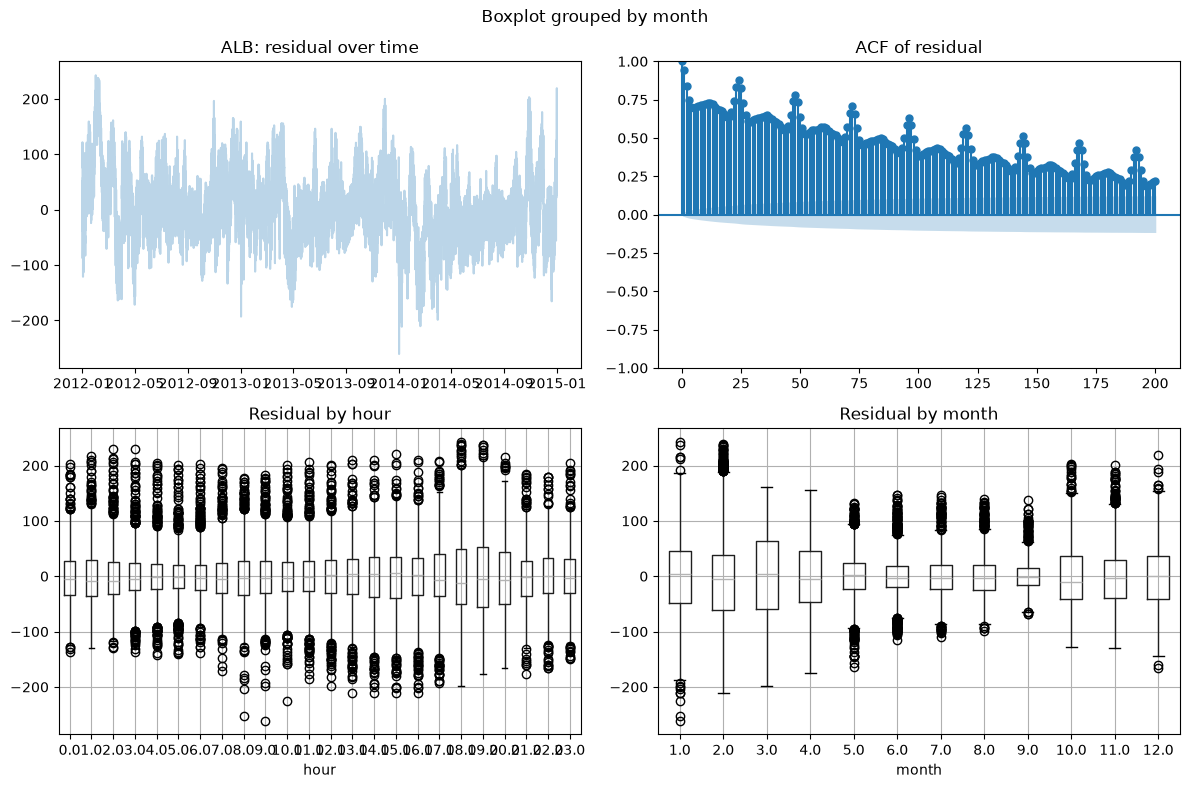

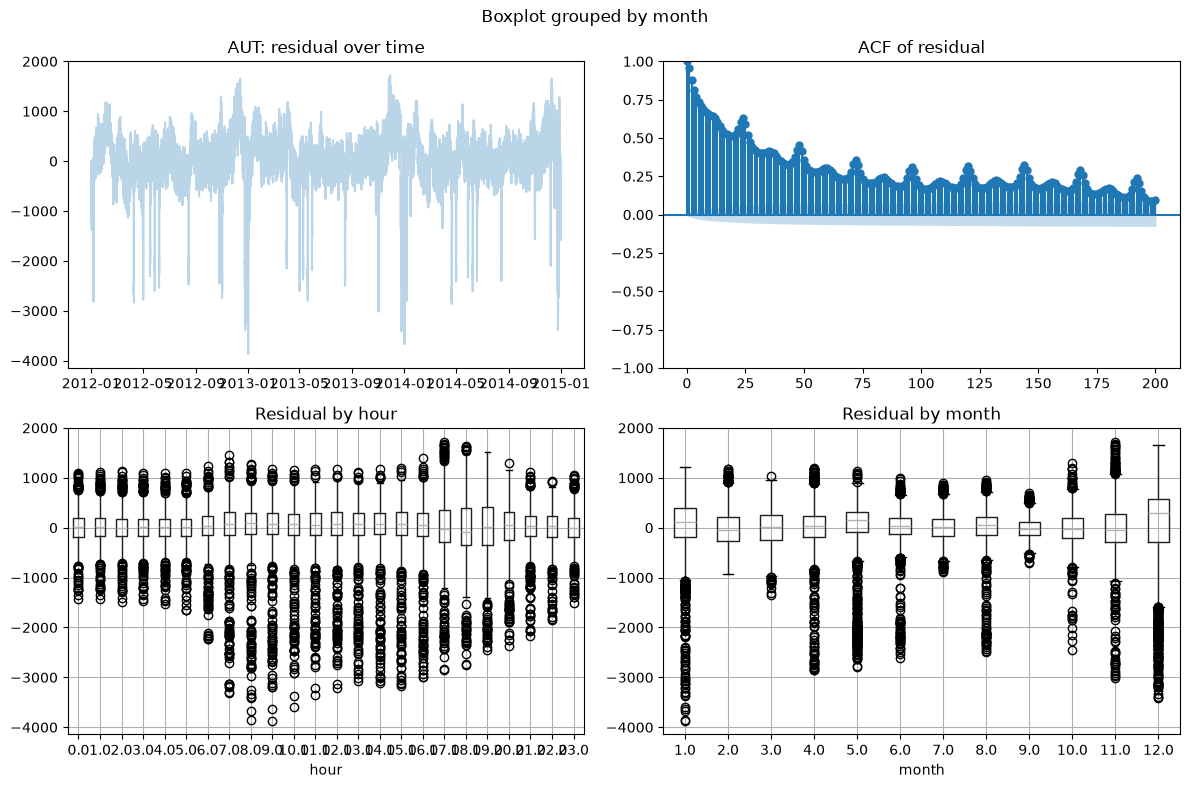

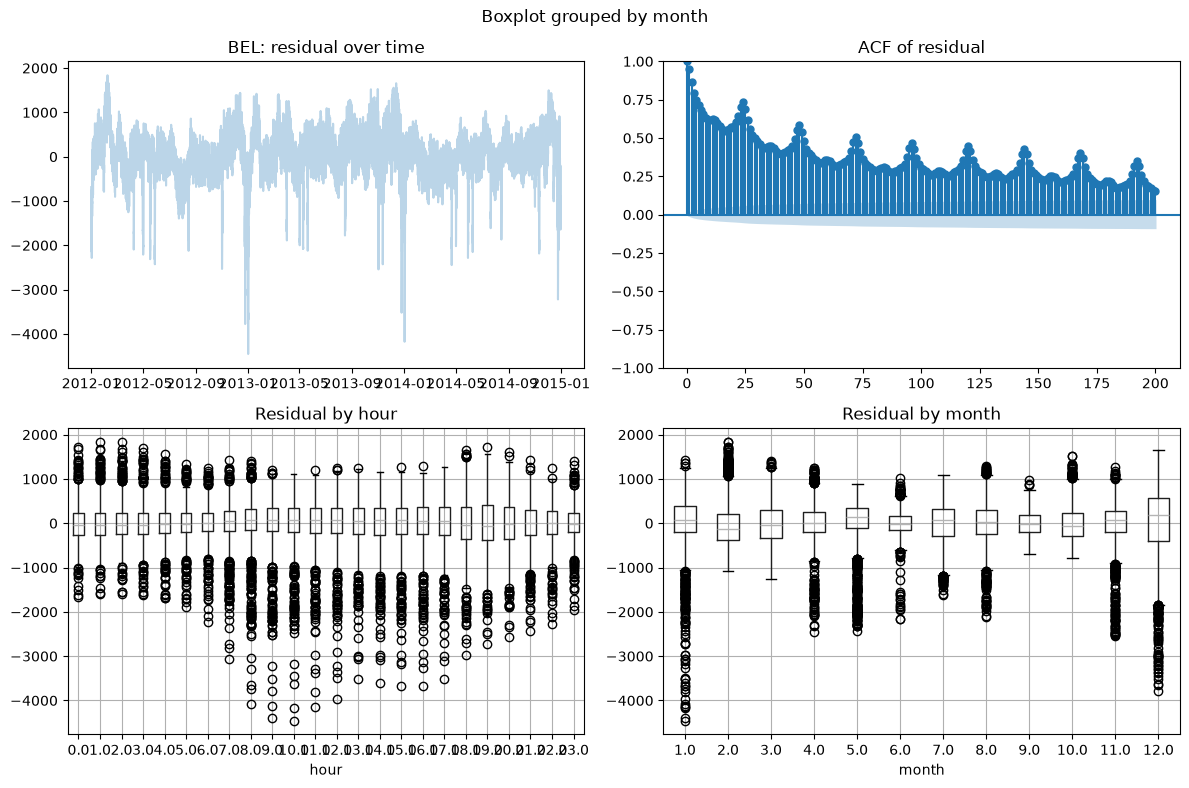

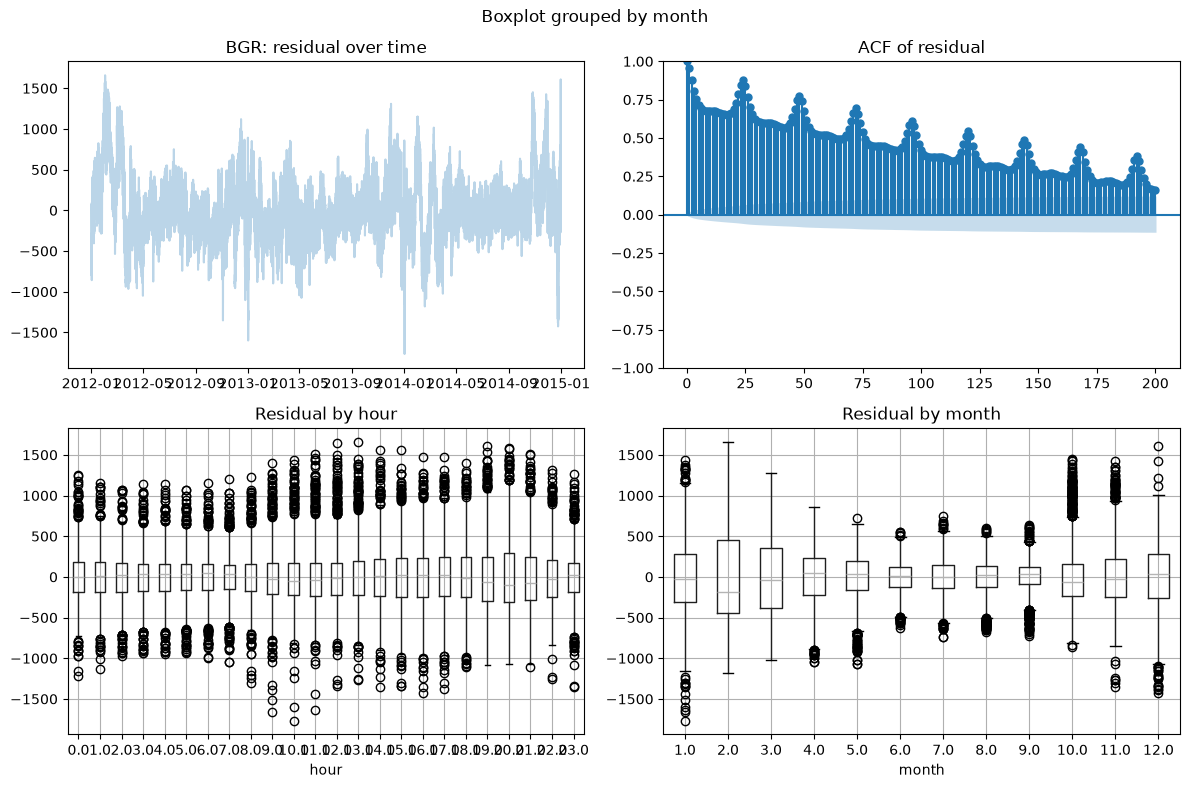

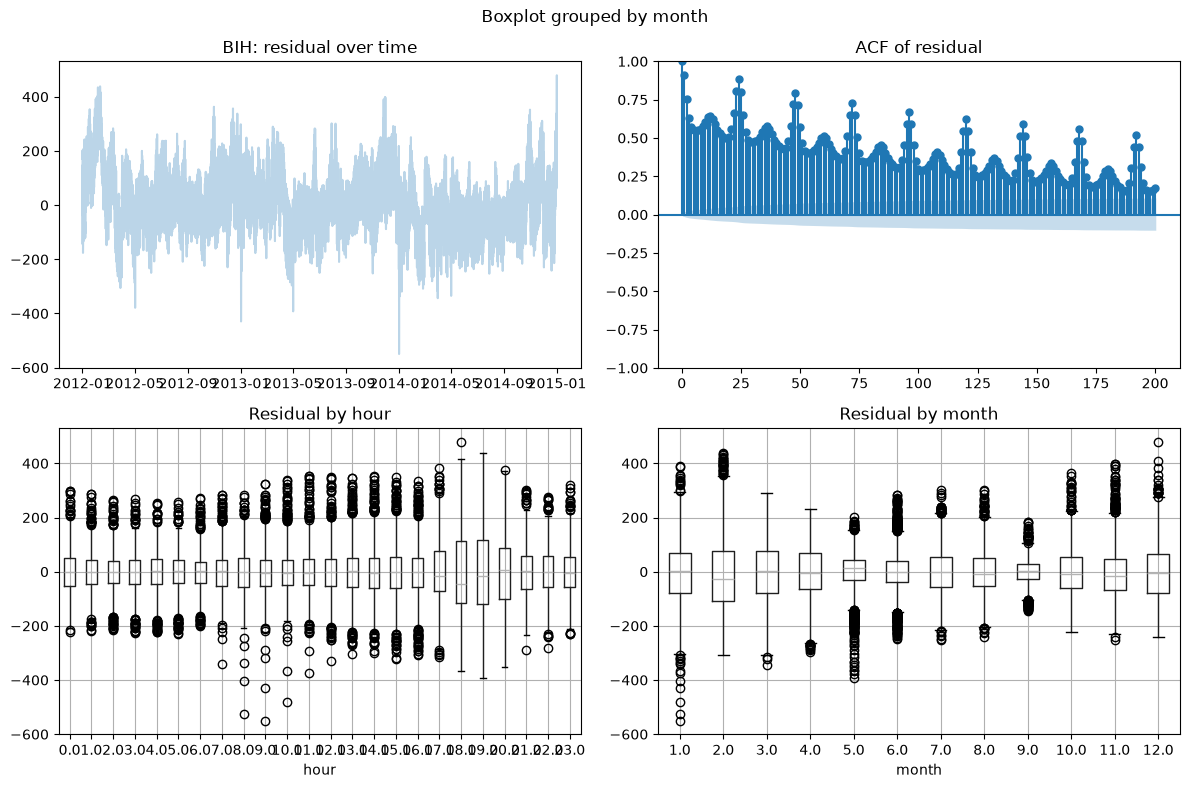

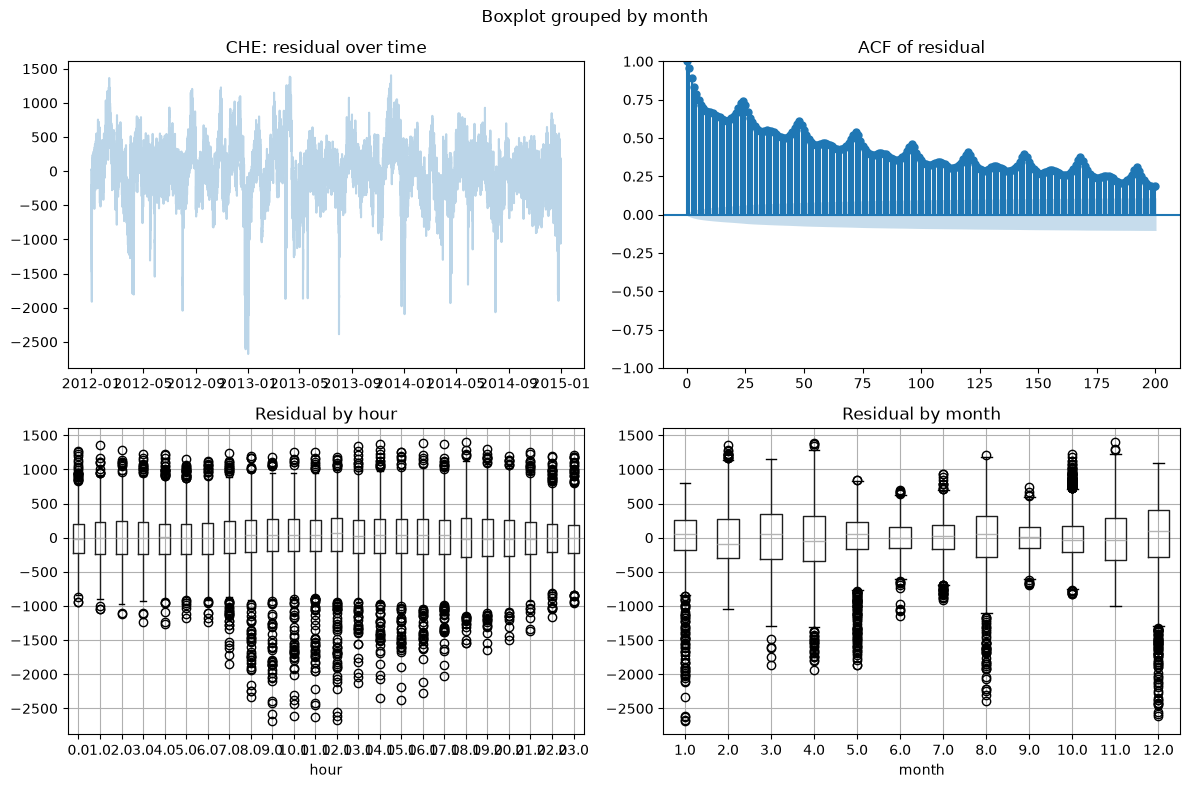

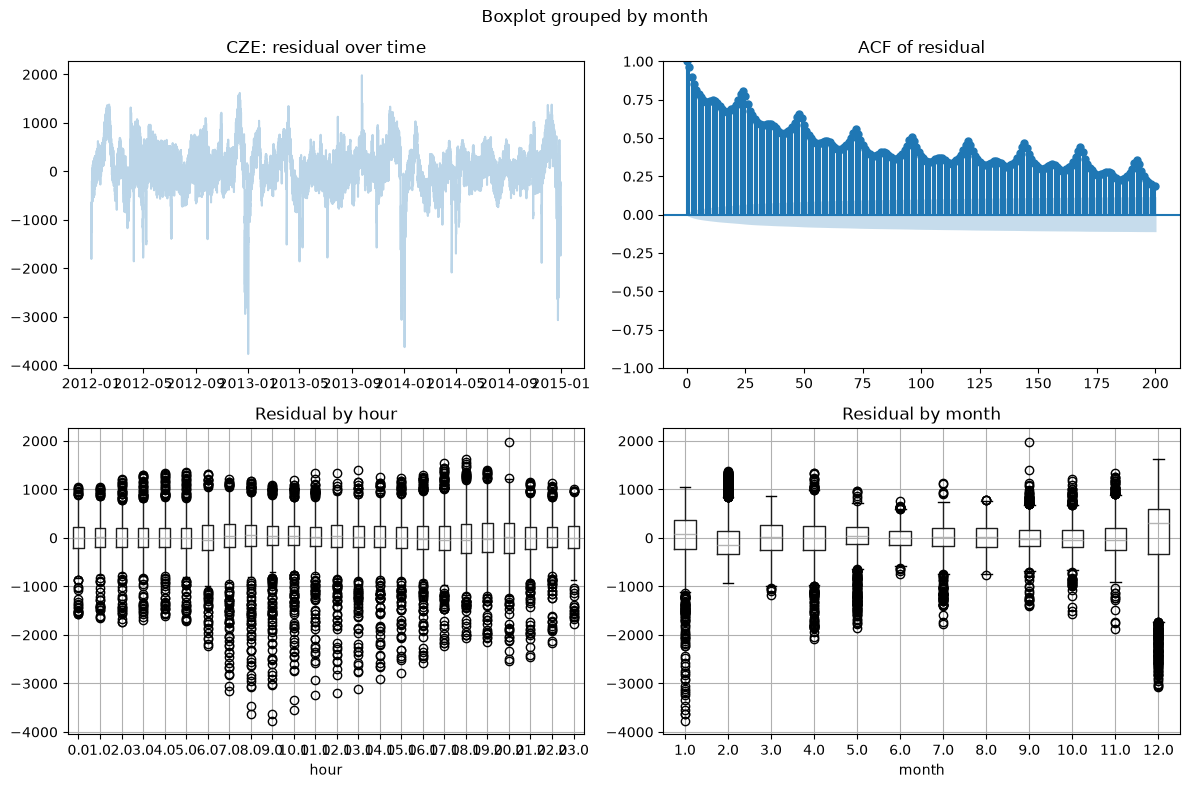

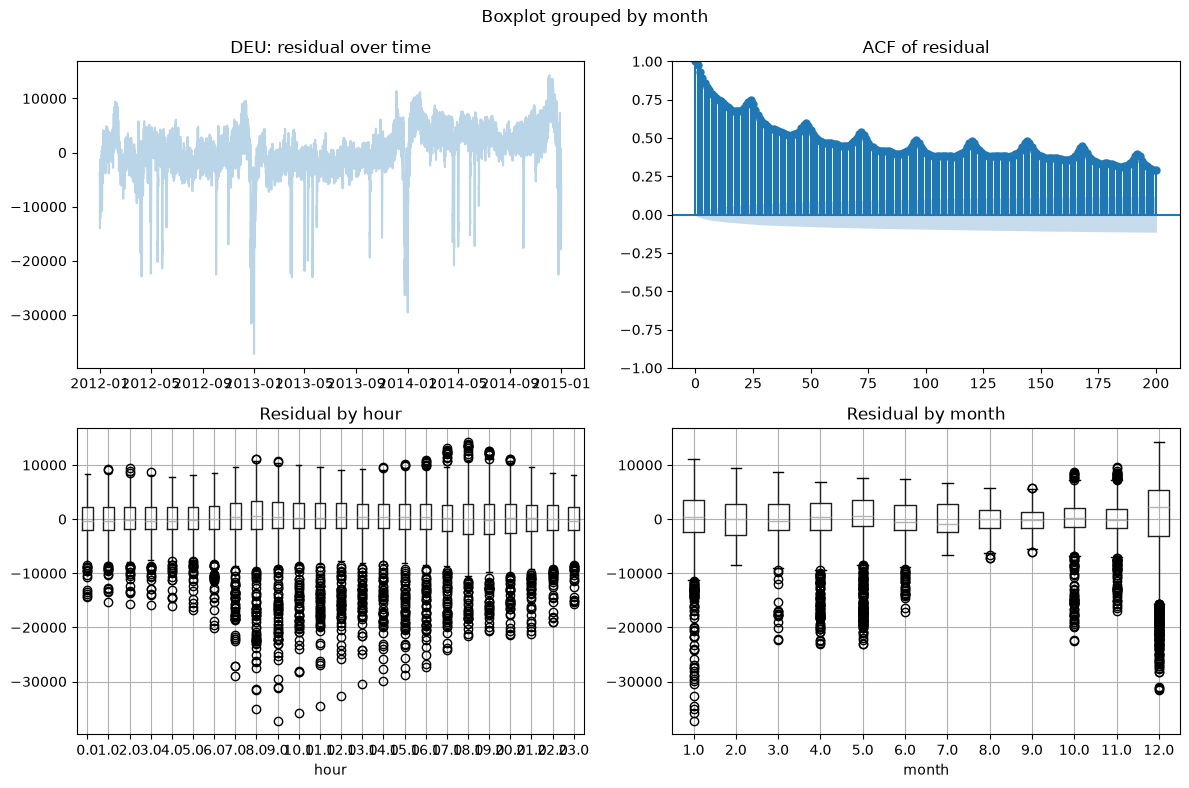

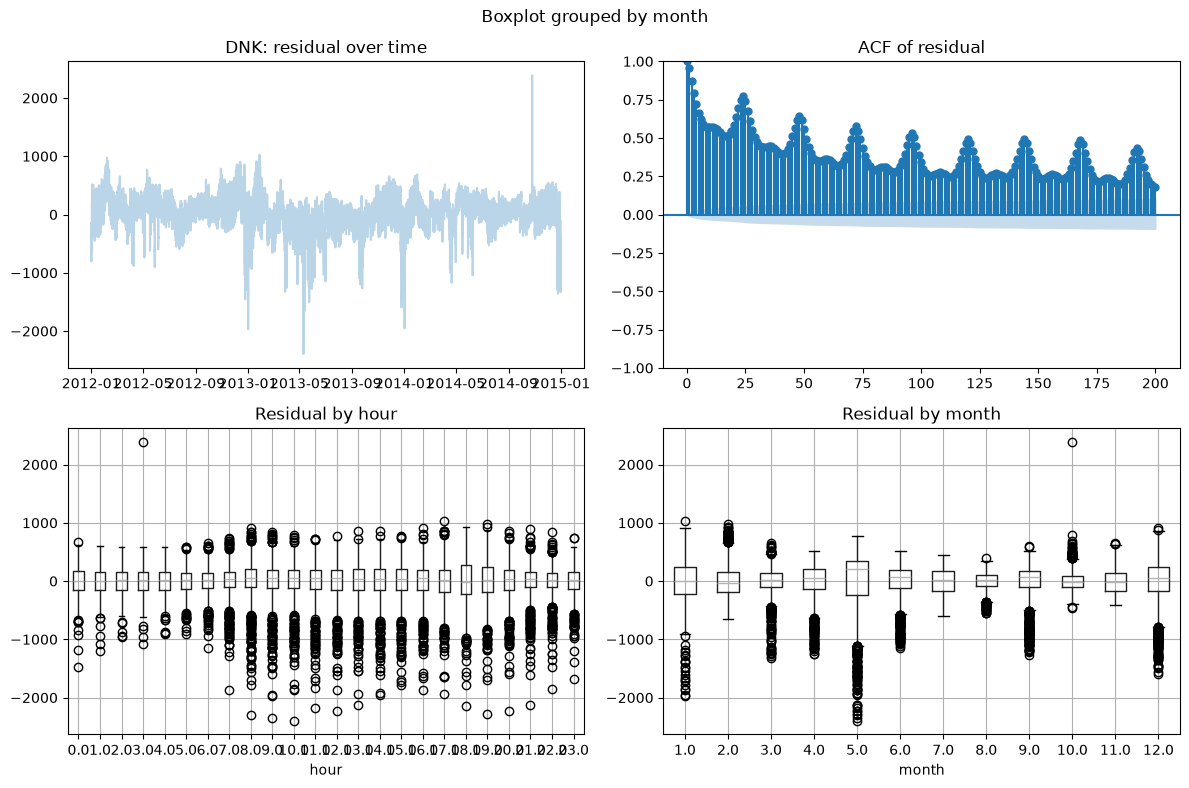

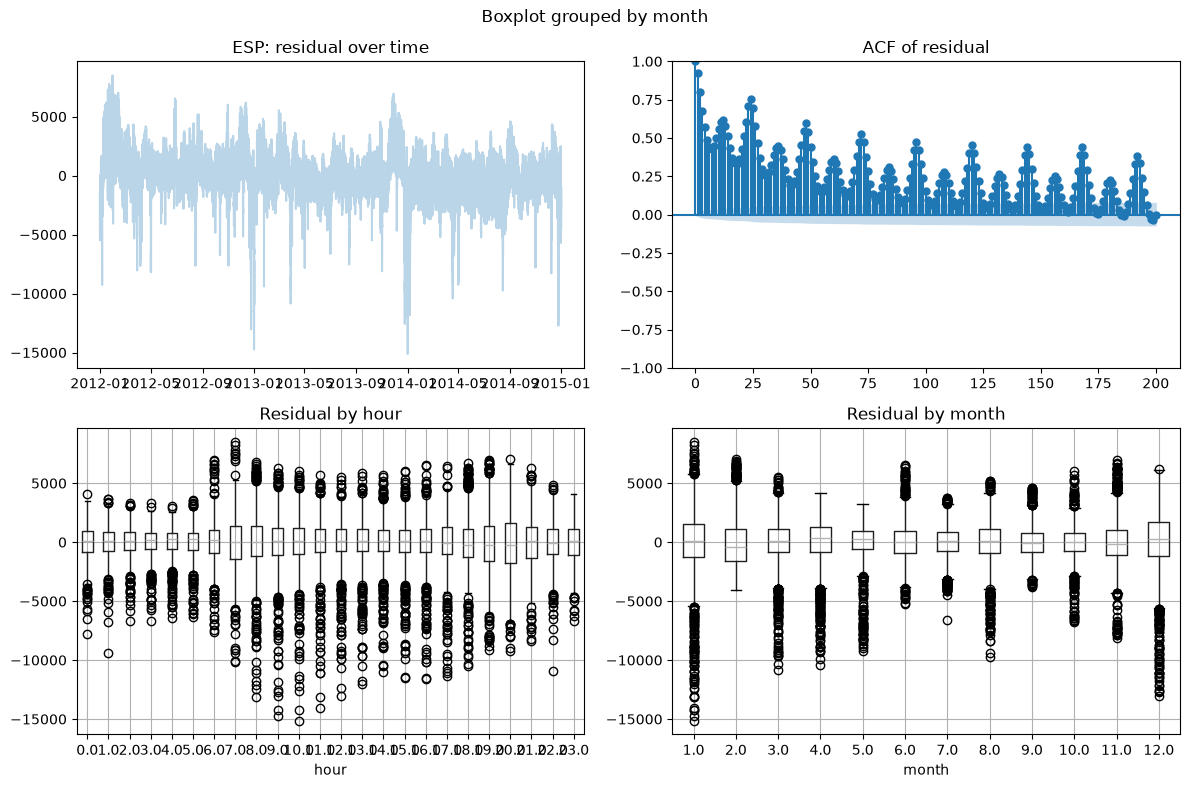

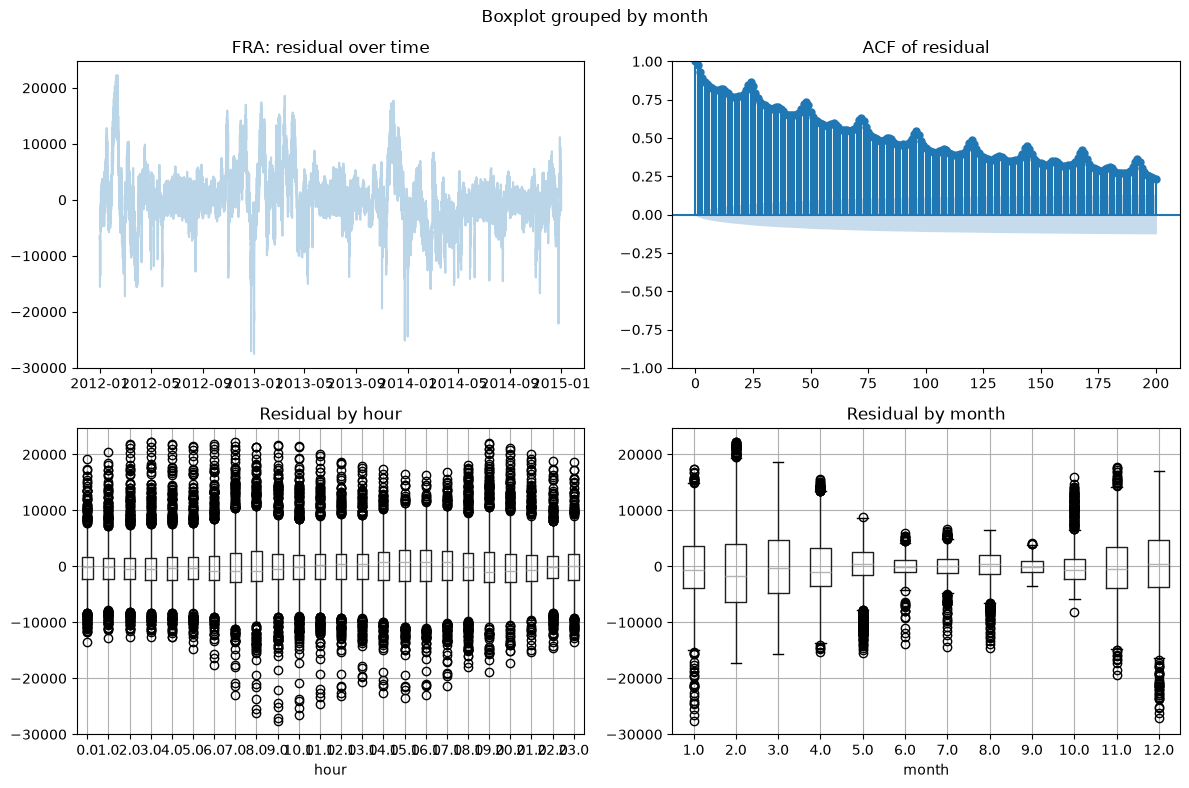

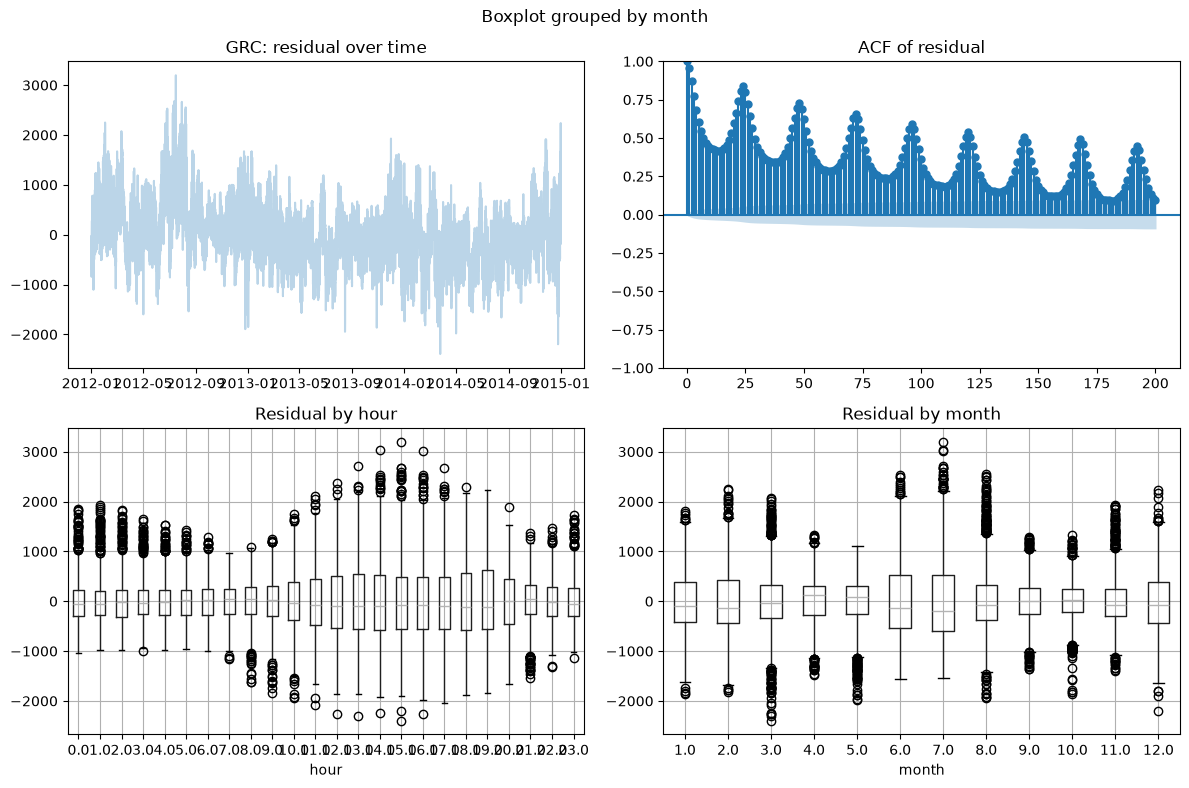

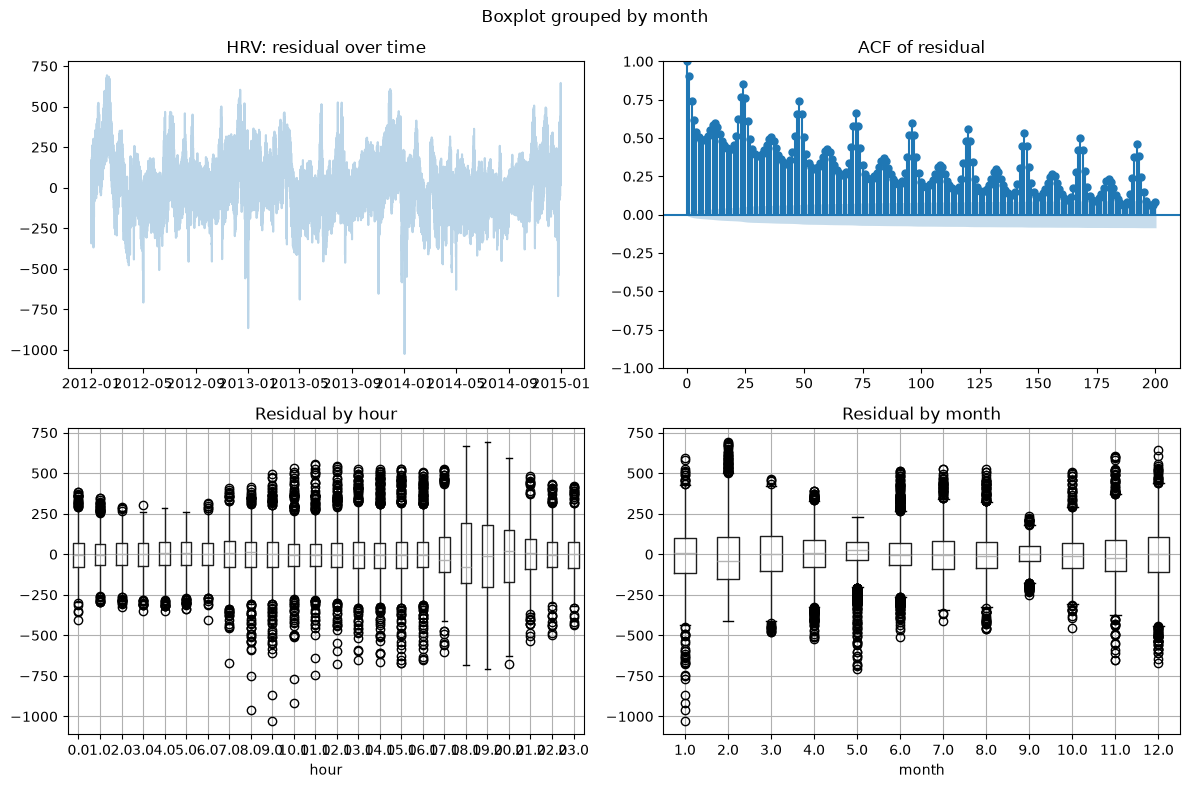

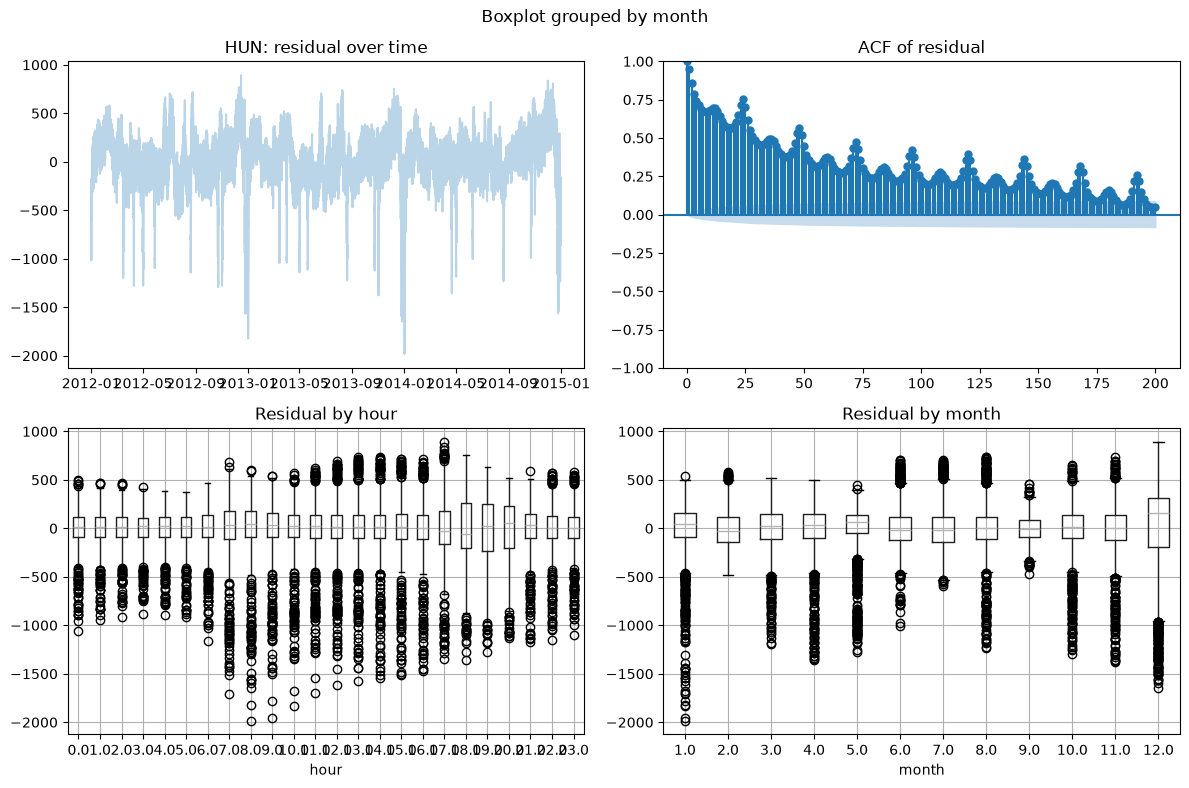

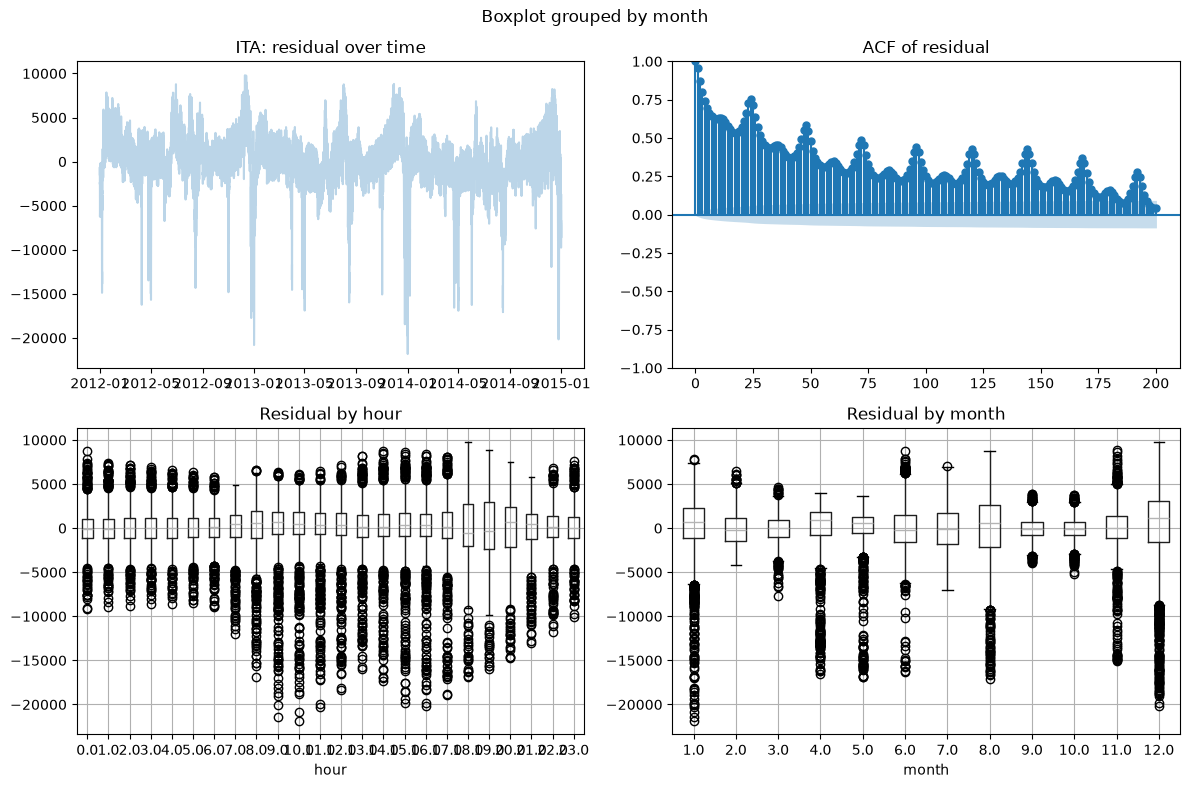

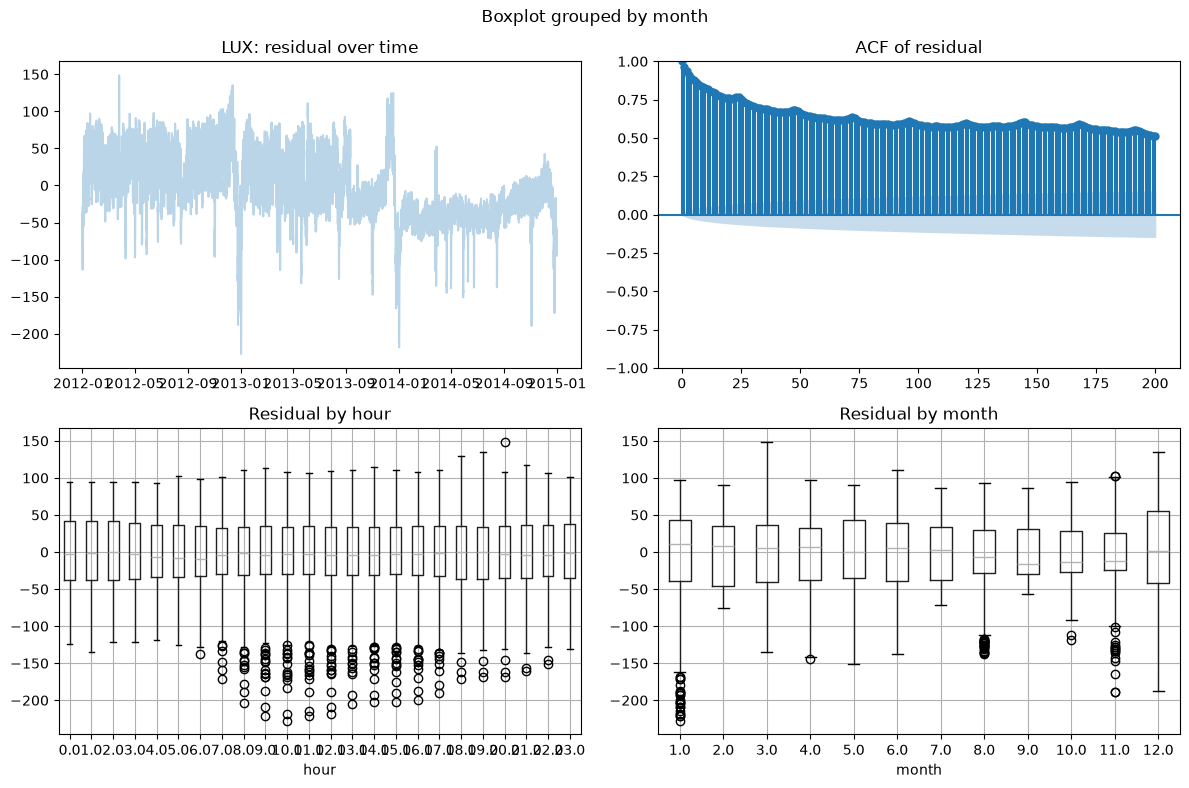

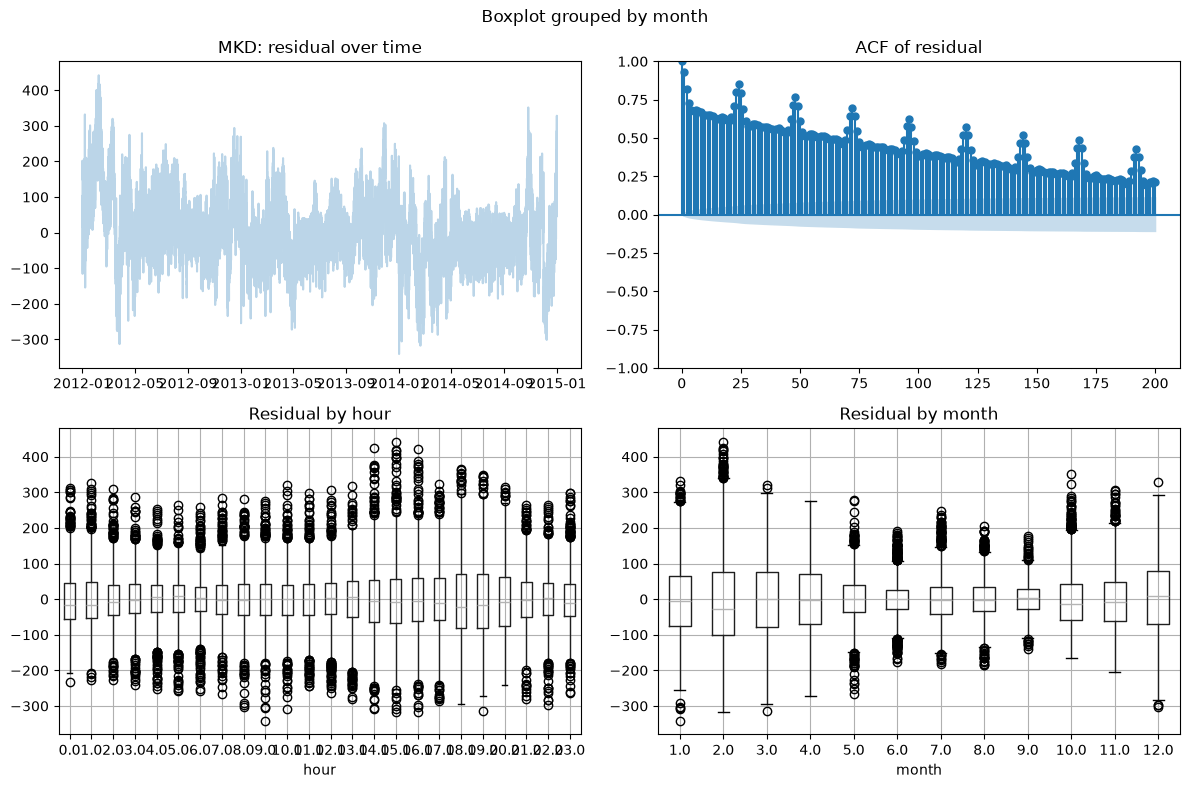

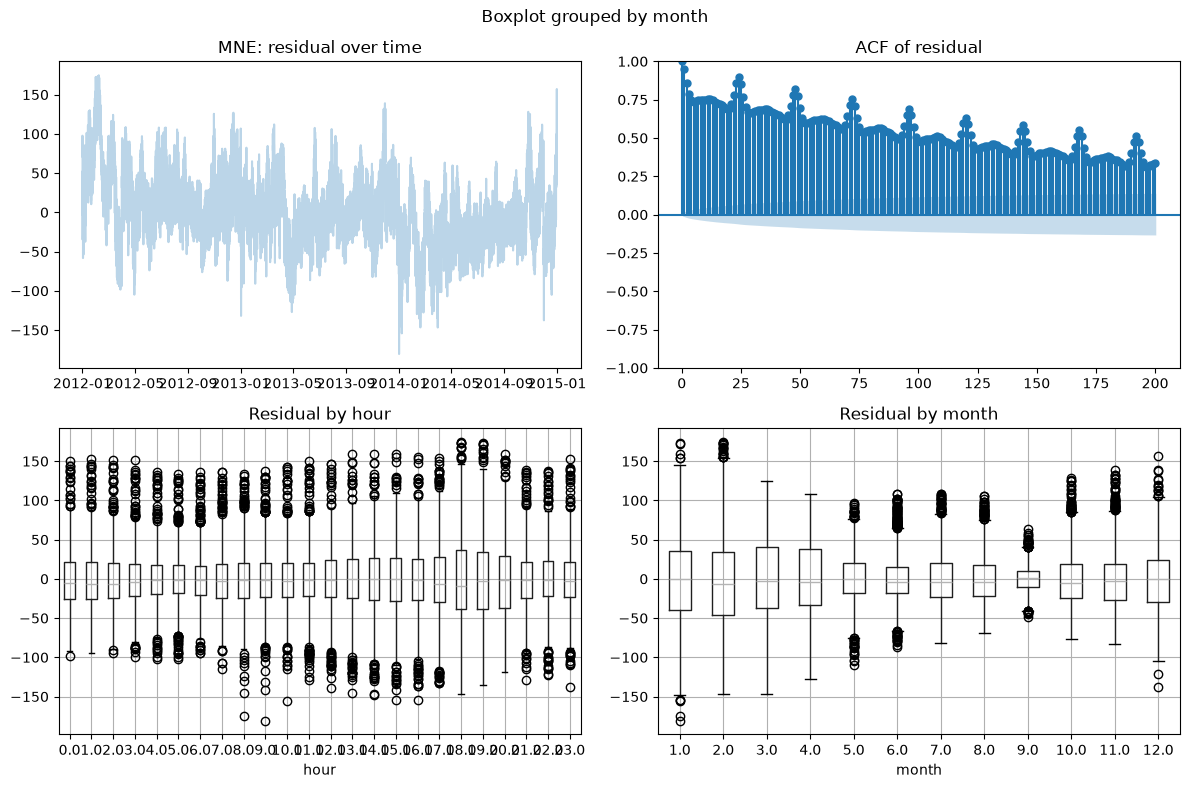

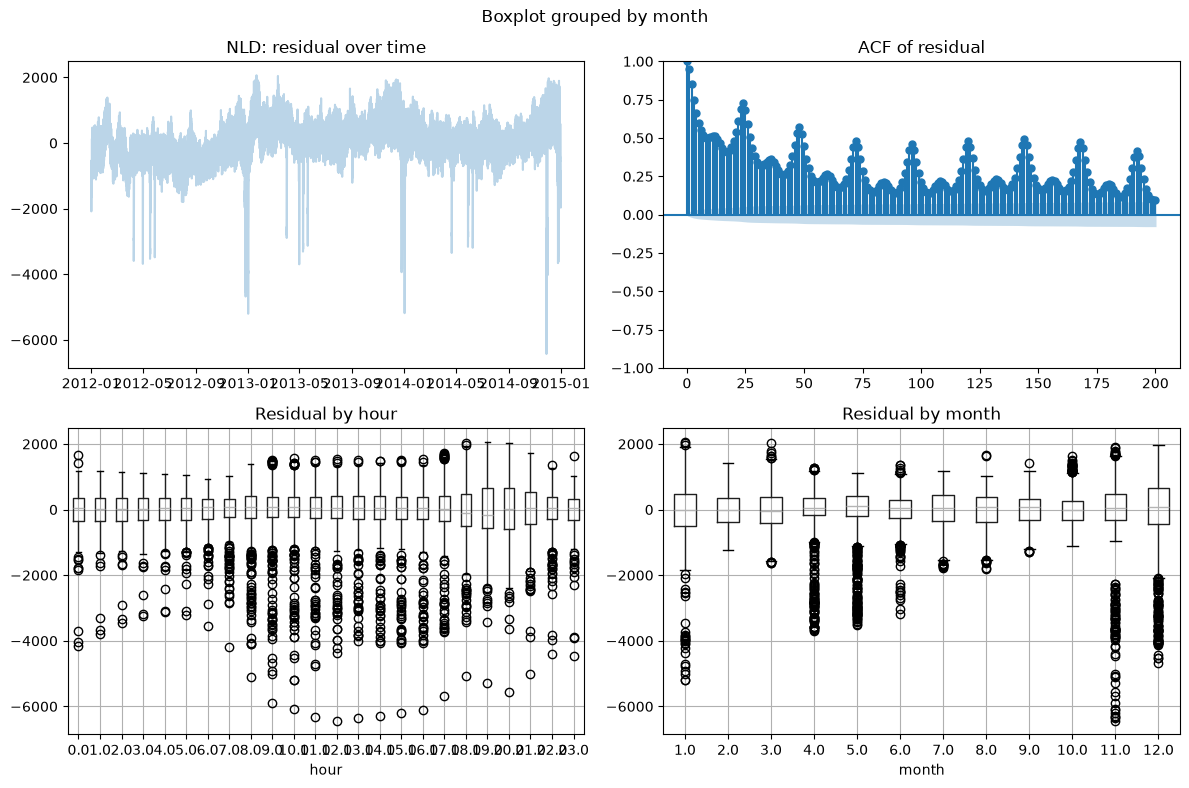

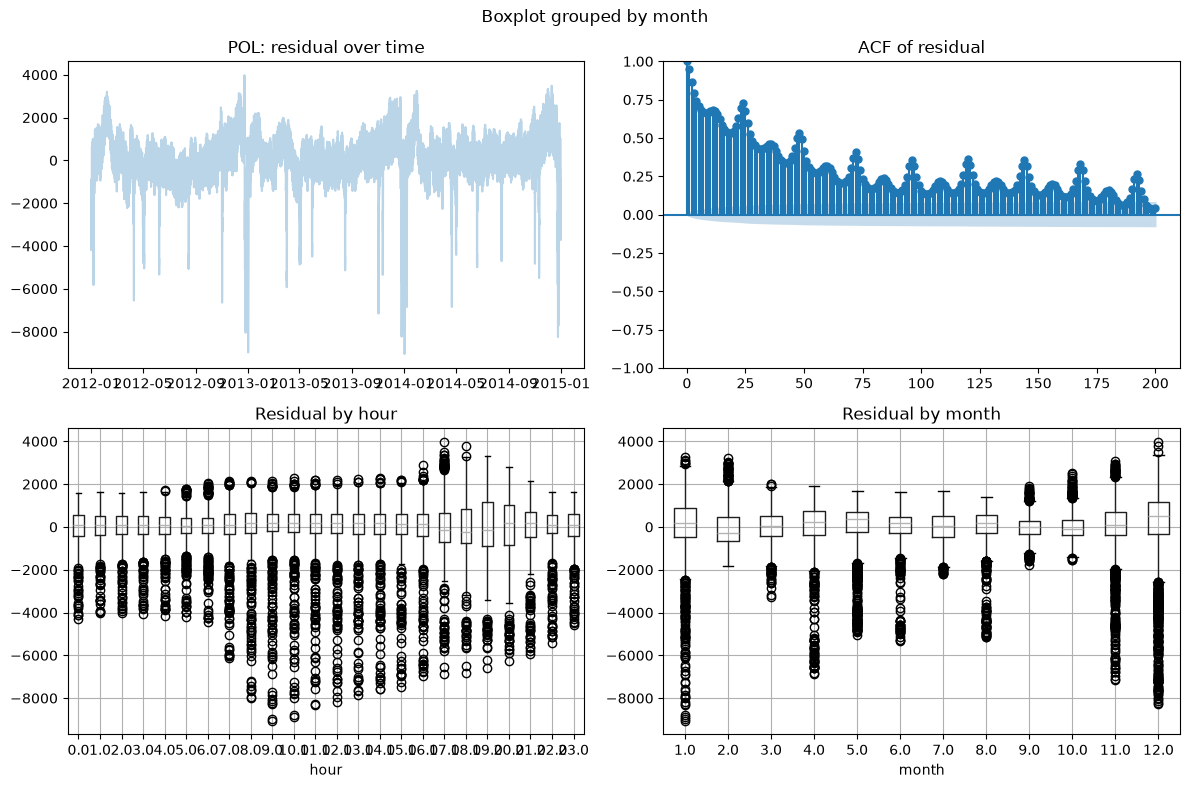

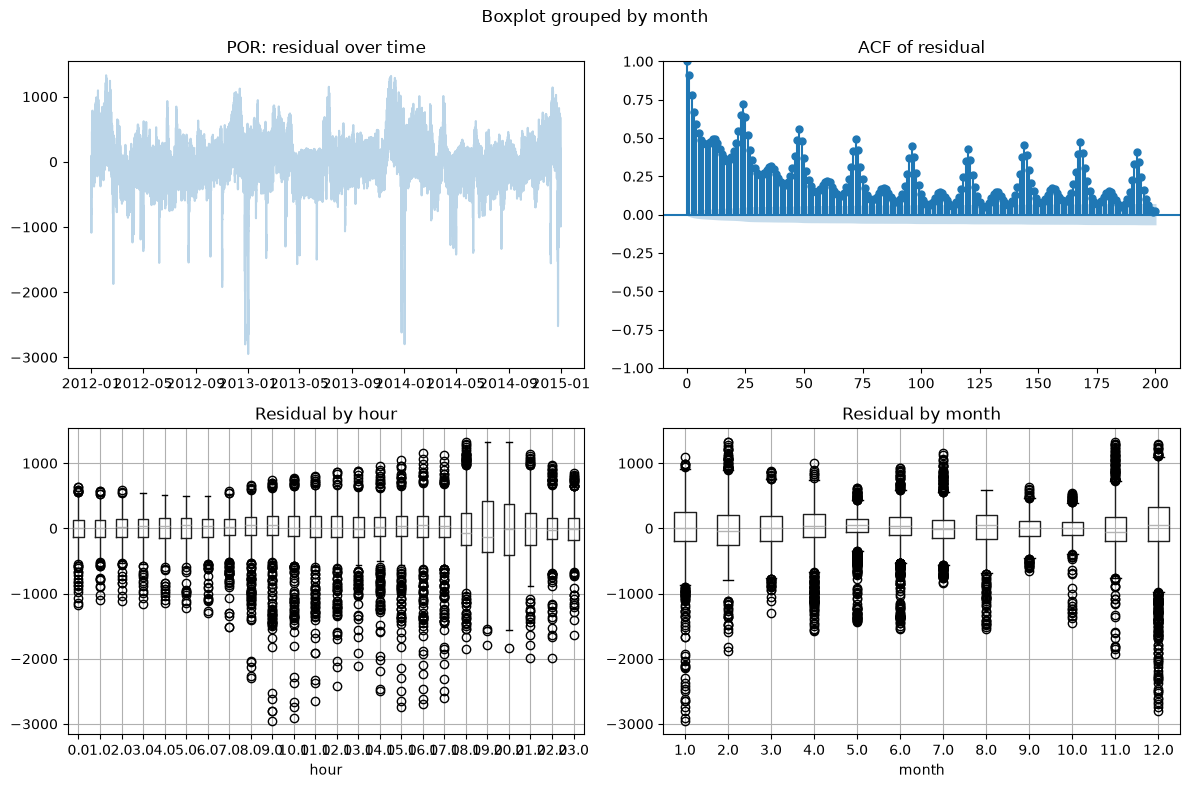

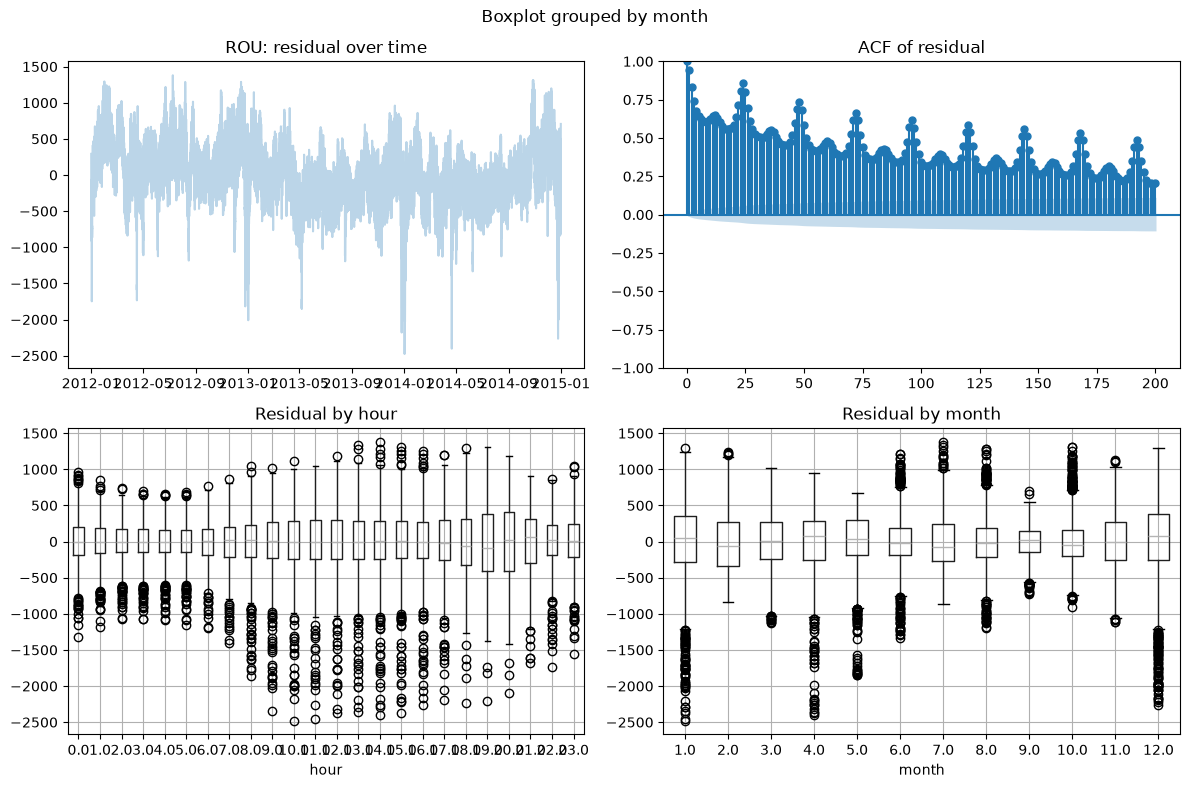

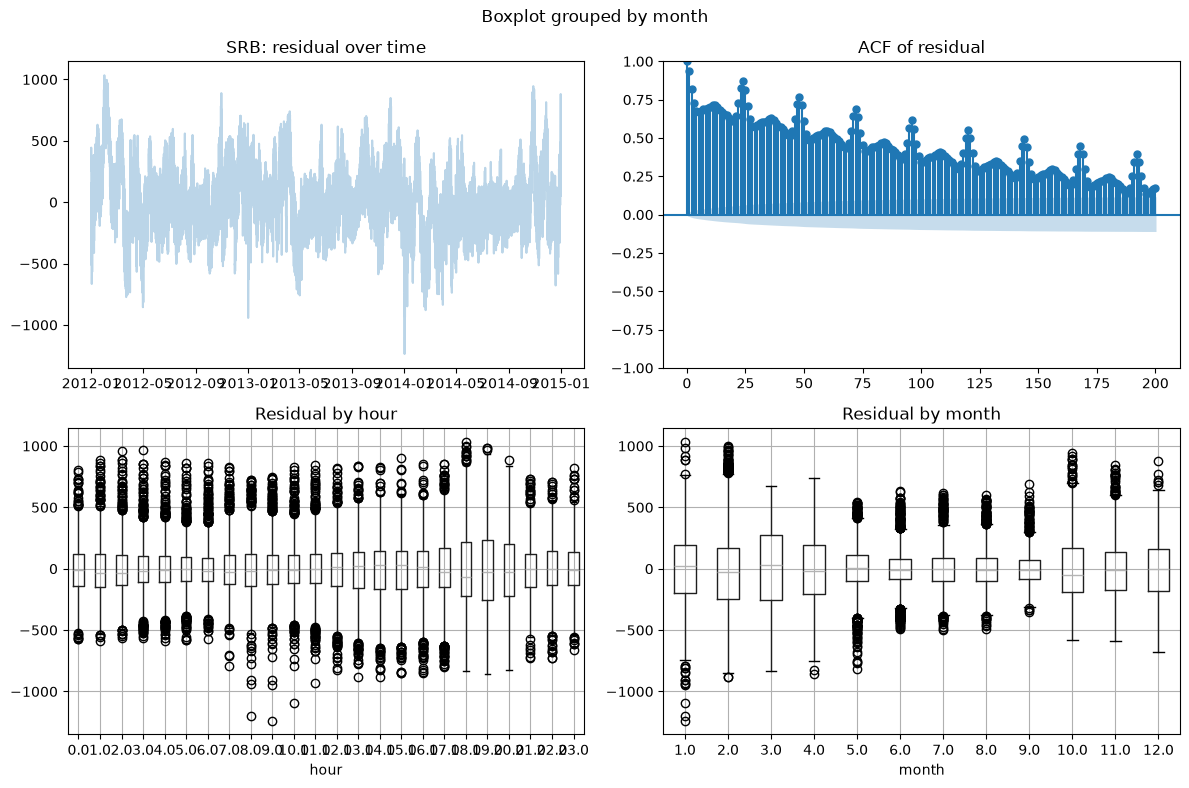

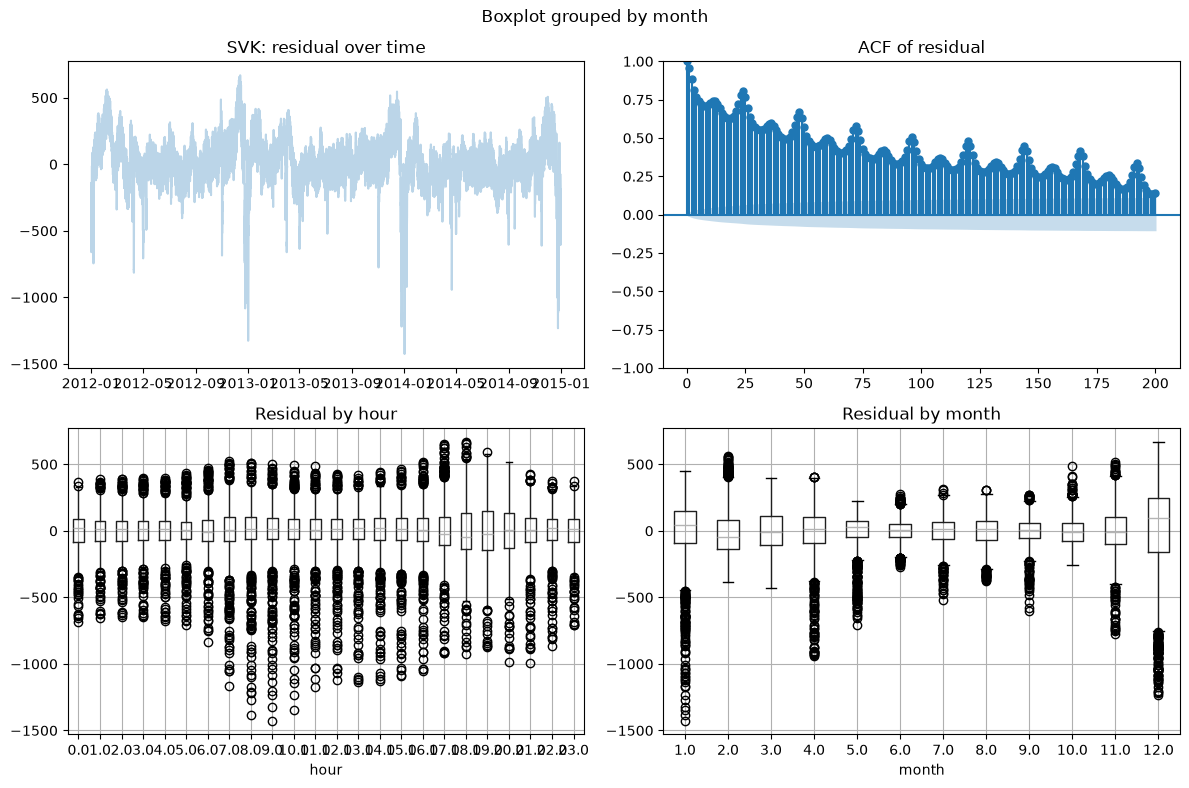

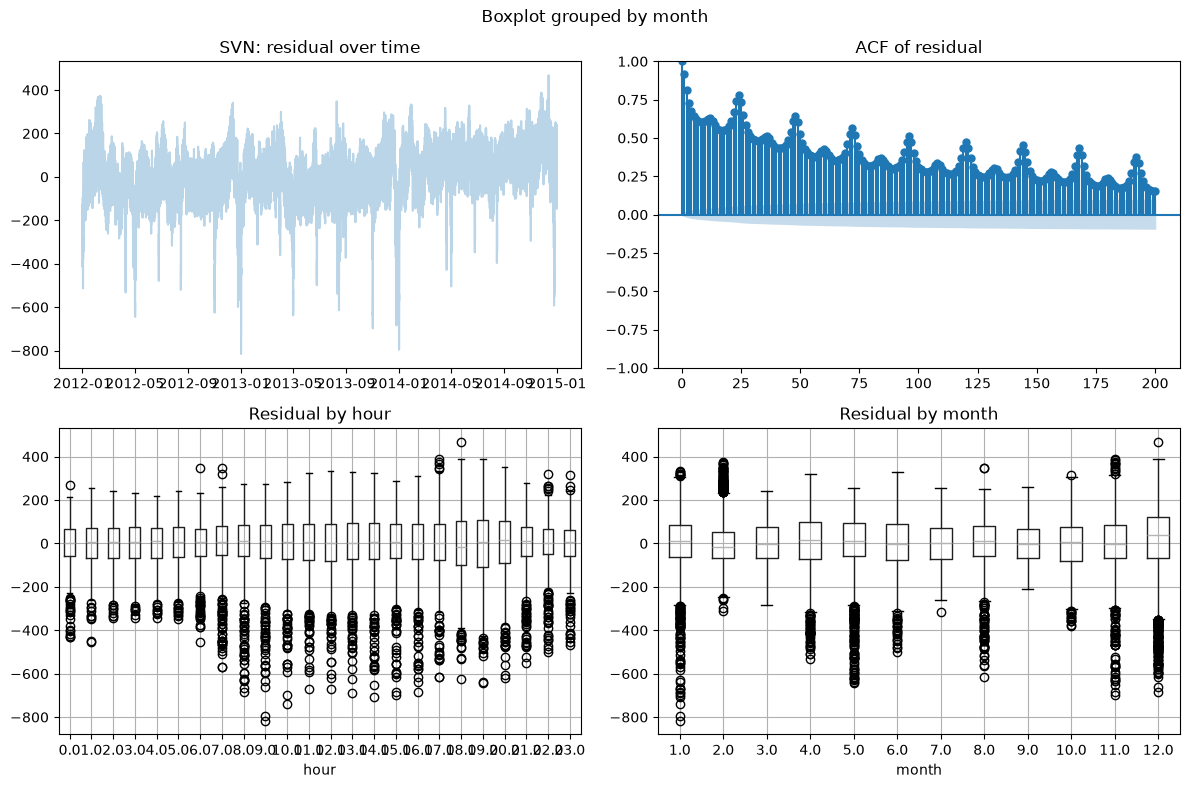

In [ ]:
import matplotlib.pyplot as plt

for country_code, res in results.items():
    data = res['data']
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Time series of residual
    axes[0, 0].plot(data['Time'], data['residual'], alpha=0.3)
    axes[0, 0].set_title(f'{country_code}: residual over time')
    
    # ACF of residual
    sm.graphics.tsa.plot_acf(data['residual'].dropna(), lags=200, ax=axes[0, 1])
    axes[0, 1].set_title('ACF of residual')
    
    # Residual by hour
    data.boxplot(column='residual', by='hour', ax=axes[1, 0])
    axes[1, 0].set_title('Residual by hour')
    
    # Residual by month
    data.boxplot(column='residual', by='month', ax=axes[1, 1])
    axes[1, 1].set_title('Residual by month')
    
    plt.tight_layout()